# Task 3 — Final Evaluation and Ultimate Judgement

This notebook assesses the selected **single Gender MixUp 0.20 refit at epoch 30** and
**single teacher-only Usage E8 refit at epoch 30**. It uses only these two models' predictions.
All model comparisons and choice reasoning belong to `06_task3_part1_gender_usage.ipynb`.

**Run All** verifies the saved artifacts, rebuilds their scores and draws the analysis.
It does not train, adjust a model or run new inference. The Gender predictions were made
with the exact completed full-development MixUp checkpoint. Usage uses the saved E8 refit
predictions. Scores, class errors, confidence, uncertainty and practical limits stay attached
to those exact artifacts throughout the notebook.


## 1. Evaluation contract

The population is the **5,778 reserved teacher images** in `data/processed/splits.csv`.
Gender uses the original five teacher labels. Usage uses the original nine-class map,
including literal `NA`; Home contributes zero F1 when it has no examples. Images are joined
by ID. Families and IDs do not cross from development into this evaluation population.

Primary metric for each target: macro-F1 over its fixed class map. Accuracy is reported
alongside it. Macro-F1 gives classes equal weight; accuracy gives images equal weight.
Neither one alone describes rare-class reliability.

The development study fixes the model and prediction rule used for this evaluation.
No changes are made after these scores. The teacher did not supply test labels; official
test images remain prediction-only and do not appear in these scores.


## 2. Verify the selected artifacts and saved predictions

The reader checks the checkpoint identities and saved file hashes, then recomputes metrics
from the selected refits' probabilities. It checks the fixed class order, unique IDs, matching
rows and probability sums. Usage's training source is checked at its recorded Git commit;
the notebook does not rely on later shared-code changes to reproduce old training.


In [1]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

EVAL_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p/'src/fashion').is_dir())
sys.path.insert(0, str(EVAL_ROOT/'src'))
from fashion.task3_refit_evaluation import load_selected_evaluation, class_table
from fashion.task3_refit_evaluation import confusion_figure, reliability_table
evaluation = load_selected_evaluation(EVAL_ROOT)
gender = evaluation['Gender MixUp']
usage = evaluation['Usage E8']
FINAL_FIGURES = EVAL_ROOT/'results/figures/task3/selected_refit_evaluation'
FINAL_FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False})
print('Verified selected refits and 5,778 matching scored IDs per target.')


Verified selected refits and 5,778 matching scored IDs per target.


## 3. Fixed models entering evaluation

**Gender:** SmallCNN with GeM pooling, 390,181 parameters, trained from scratch with MixUp
alpha 0.20 and dropout 0.30 for 30 epochs. The completed refit uses all 32,773 development
images and the fixed name-corrected training labels. Evaluation uses original teacher labels.
No name rule changes these reference labels or the predictions.

**Usage:** the scratch SmallCNN E8 refit uses average pooling, effective-number class weights
and small training translations. It trains on 32,772 eligible teacher development images for
30 epochs. The blank Usage target is excluded; literal `NA` remains a class. No outside images
enter the selected refit.

Both fits are registered in `results/runs.csv`. Their weights start fresh for the full-development
refit. The five-fold development scores belong to the fold models; they are not scores for these
refits. Each refit uses one saved checkpoint, not an ensemble.


## 4. Fixed preprocessing and prediction rule

Each photo is oriented from EXIF, resized while keeping its shape, and centred on an 80-pixel-high,
60-pixel-wide canvas. Each model uses its own saved RGB means and standard deviations fitted
to development content pixels, with padding excluded. Transformed padding is zero.

Prediction uses evaluation mode, softmax, then the largest probability in the saved class order.
Training augmentation, dropout and MixUp are inactive. Nothing is fitted on evaluation images.
The file hashes below identify the exact checkpoint and normalization, so similarly named
artifacts cannot silently substitute for the selected model.


In [2]:
for name, item in evaluation.items():
    model = item['manifest']
    print(name, '—', model['run_id'])
    print('Checkpoint:', model['checkpoint']['path'])
    print('SHA-256:', model['checkpoint']['sha256'])
    print('Class order:', ', '.join(model['class_names']))
    statistics = json.loads((EVAL_ROOT/model['normalization']['path']).read_text())
    display(pd.DataFrame({'Channel':list('RGB'), 'Mean':statistics['mean'],
        'Standard deviation':statistics['std']}).set_index('Channel').round(6))


Gender MixUp — t3_gender_name_truth_mixup_alpha020_refit_20260911T041436Z_3af0b94e
Checkpoint: reports/task3/gender_mixup_selection_20260911/refit/t3_gender_name_truth_mixup_alpha020_refit_20260911T041436Z_3af0b94e/final_epoch.pt
SHA-256: 860f688162cccfcd903e8e4874b368697c0637b6e6a15baae3b4d4a3008f4ef9
Class order: Boys, Girls, Men, Unisex, Women


,Mean,Standard deviation
Channel,,
R,0.849999,0.271111
G,0.833254,0.282661
B,0.827607,0.286203


Usage E8 — t3_usage_e8_translation_teacher_all_development_refit_5553be0c138243e9
Checkpoint: results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt
SHA-256: 18da75a4ec935ab0d18c9ebdf9d1dabb6fa87ee484ead5f439de0192c4af2747
Class order: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel


,Mean,Standard deviation
Channel,,
R,0.849998,0.271110
G,0.833253,0.282661
B,0.827605,0.286203


## 5. Prediction freeze and scoring

The Gender evaluation script verifies the completed 30-epoch checkpoint and every evaluation
image hash. It records the fixed plan, produces probabilities with unchanged weights and buffers,
then saves the prediction file and its hash **before joining protected reference labels**.
The recorded scorer uses IEEE float32 on CPU with two threads and batch size 32.

The saved Usage E8 freeze identifies the same single-checkpoint prediction rule and unchanged
weights. This notebook reads only that refit's probabilities and labels. It does not regenerate
predictions or select an epoch based on this evaluation.

The saved image and family checks establish separation from training.


## 6. Overall results of the selected refits

Read the two targets separately: they have different class maps and difficulty. A larger Gender
score does not establish a better learning method than Usage. Each row below is recomputed from
the selected model's saved probabilities and the original reference labels.


In [3]:
summary_rows = []
for name, item in evaluation.items():
    m = item['metrics']
    correct = int(np.trace(np.asarray(m['confusion_matrix'])))
    summary_rows.append([name, m['support'], correct, m['support']-correct,
        100*m['macro_f1'], 100*m['accuracy'], m['nll'], m['brier'], 100*m['ece_15']])
summary = pd.DataFrame(summary_rows, columns=['Model', 'Images', 'Correct', 'Wrong',
    'Macro-F1 (%)', 'Accuracy (%)', 'NLL', 'Brier', 'ECE, 15 bins (%)']).set_index('Model')
display(summary.round(4))


,Images,Correct,Wrong,Macro-F1 (%),Accuracy (%),NLL,Brier,"ECE, 15 bins (%)"
Model,,,,,,,,
Gender MixUp,5778,5227,551,78.7431,90.4638,0.2873,0.1444,1.6995
Usage E8,5778,5125,653,42.2559,88.6985,0.3173,0.1706,0.9519


**Gender MixUp:** 5,227 correct and 551 wrong, giving **90.46% accuracy and 78.74% macro-F1**.
The 11.72-point difference between those scores reflects uneven class performance. It is not a
training gap: both numbers describe the same evaluation predictions.

**Usage E8:** 5,125 correct and 653 wrong, giving **88.70% accuracy and 42.26% macro-F1**.
The large difference shows why the high image-level accuracy is insufficient. Many correct
Casual images coexist with weak rare-class coverage.

These are measurements of the two refits. They do not prove that every development advantage
will repeat, or that a model meets a shop's requirements. No acceptance threshold for unattended
tagging was fixed and validated.


## 7. Gender: class performance and mistakes

The Gender class table reports support, prediction count, correct and missed items, precision,
recall and F1. Precision asks how often a suggested class is right. Recall asks how many actual
members of that class are found. Both matter when reviewing catalogue tags.


,support,predicted_count,correct,missed,precision,recall,f1
class_name,,,,,,,
Boys,120,138,95,25,68.84,79.17,73.64
Girls,95,105,73,22,69.52,76.84,73.00
Men,3130,3215,2964,166,92.19,94.70,93.43
Unisex,311,240,171,140,71.25,54.98,62.07
Women,2122,2080,1924,198,92.50,90.67,91.58


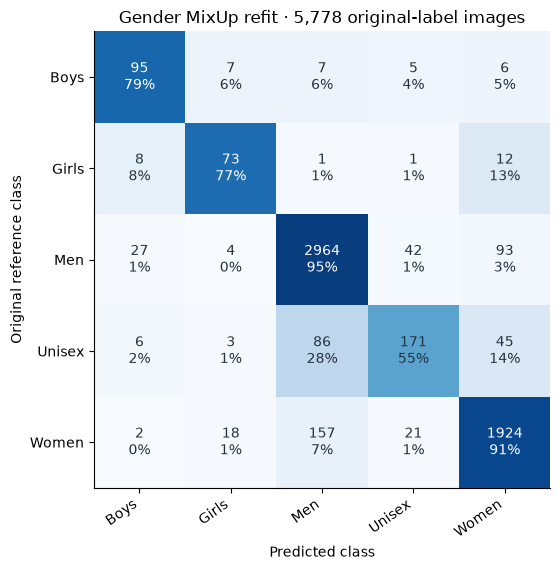

In [4]:
gender_classes = class_table(gender)
display(gender_classes.round(2))
fig = confusion_figure(gender, 'Gender MixUp refit · 5,778 original-label images')
fig.savefig(FINAL_FIGURES/'gender_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


**Men and Women dominate the correct predictions.** Men F1 is 93.43% and Women F1 is 91.58%.
However, 157 Women images become Men and 93 Men images become Women. These two directions
account for 250 of the 551 mistakes, so the common classes still create substantial review work.

**Boys and Girls are less precise.** Boys recall is 79.17%, but precision is 68.84%:
95 of 138 Boys suggestions are right. Girls recall is 76.84%, with precision 69.52%:
73 of 105 Girls suggestions are right. Small support, 120 Boys and 95 Girls, makes these
estimates less stable than the adult-class estimates.

**Unisex is the clearest unresolved weakness.** The model finds 171 of 311 products, or
54.98% recall. It misses 140, including 86 predicted as Men and 45 as Women. Unisex F1 is
62.07%; 69 of the 240 Unisex predictions are false positives. A low detection rate and a
meaningful false-positive count both argue for review rather than trusting the tag automatically.

The confusion matrix locates mistakes; it does not show which visual features caused them.
An audience label can depend on sizing or product text that is not visible in a small image.
That is a plausible limit, not a reason to treat every wrong prediction as a bad reference label.


### Inspect selected Gender errors

For each true class, show the two most confident mistakes, breaking ties by ID. This fixed
selection rule makes the gallery reproducible. The examples are deliberately difficult cases,
not a random sample and not an estimate of error frequency. Displayed confidence is rounded.


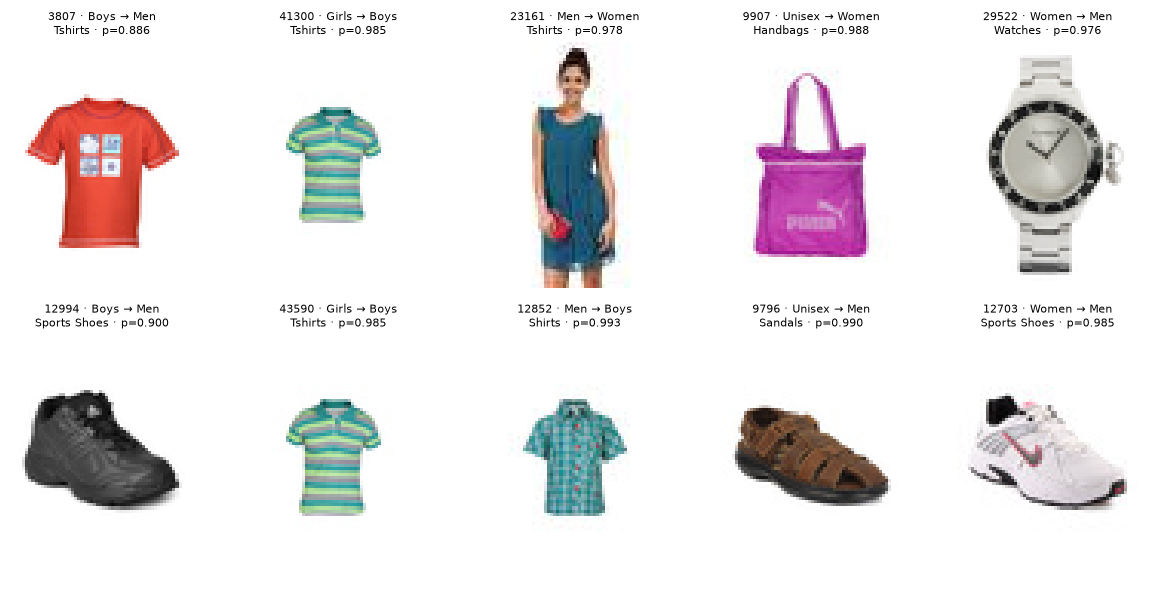

In [5]:
gender_errors = gender['rows'].loc[gender['rows'].actual.ne(gender['rows'].predicted)].copy()
gallery = gender_errors.sort_values(['confidence', 'id'], ascending=[False, True])
gallery = gallery.groupby('actual', sort=False).head(2).sort_values(['actual', 'confidence'])
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for ax, row in zip(axes.T.flat, gallery.itertuples()):
    with Image.open(EVAL_ROOT/row.path) as picture:
        ax.imshow(picture.convert('RGB'))
    ax.set_title(f'{row.id} · {row.actual} → {row.predicted}\n'
        f'{row.articleType} · p={row.confidence:.3f}', fontsize=8)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FINAL_FIGURES/'gender_error_gallery.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Usage: class performance and mistakes

Keep all nine classes in the score. Home has no examples, so its zero F1 is part of the fixed
metric convention, not evidence that all Home products would fail. For the other rare classes,
show counts before interpreting percentages.


,support,predicted_count,correct,missed,precision,recall,f1
class_name,,,,,,,
Casual,4441,4596,4199,242,91.36,94.55,92.93
Ethnic,384,372,307,77,82.53,79.95,81.22
Formal,342,299,247,95,82.61,72.22,77.07
Home,0,0,0,0,0.00,0.00,0.00
NA,10,15,1,9,6.67,10.00,8.00
Party,1,6,0,1,0.00,0.00,0.00
Smart Casual,8,18,3,5,16.67,37.50,23.08
Sports,589,468,367,222,78.42,62.31,69.44
Travel,3,4,1,2,25.00,33.33,28.57


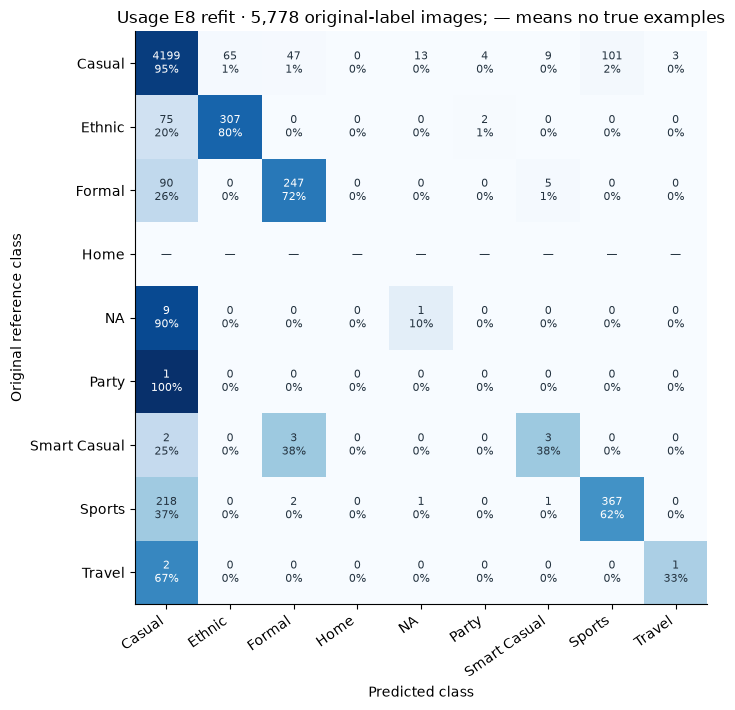

In [6]:
usage_classes = class_table(usage)
display(usage_classes.round(2))
fig = confusion_figure(usage, 'Usage E8 refit · 5,778 original-label images; — means no true examples')
fig.savefig(FINAL_FIGURES/'usage_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


**Common-class success explains much of the accuracy.** Casual contributes 4,199 correct
images from 4,441, with 92.93% F1. Ethnic reaches 81.22% F1 and Formal 77.07%. Sports is weaker:
367 of 589 are found, with 69.44% F1. The 218 Sports images called Casual are the largest
single confusion direction. Formal also loses 90 items to Casual.

**Rare-class success is too limited for a general claim.** The refit finds one of ten `NA`,
zero of one Party, three of eight Smart Casual, and one of three Travel images. Together this
is five correct out of 22. Precision is 6.67% for `NA`, 0% for Party, 16.67% for Smart Casual
and 25% for Travel. A few detections do not mean the corresponding suggestions are usually right.

The occasion classes overlap in meaning: a photograph alone may not distinguish Casual,
Smart Casual or Travel reliably. The saved errors support this as a task limitation, but do
not prove it is the only cause. Sparse families, label noise and learned catalogue cues can
also contribute. Preserve the reference labels and report the failures plainly.


## 9. Uncertainty and the size of the evidence

The saved bootstrap resamples whole product families, with replacement, 10,000 times using
seed 2753. Every draw retains the fixed five- or nine-class macro-F1 definition, including
zero for an absent class. It estimates uncertainty from this set of families for the already
trained refit. It does not estimate new-seed variation or correct repeated model selection.


,macro_f1,lower_95,upper_95,families,draws
Gender MixUp,78.743143,75.299716,81.662143,4110,10000
Usage E8,42.255917,36.615363,48.463745,4110,10000


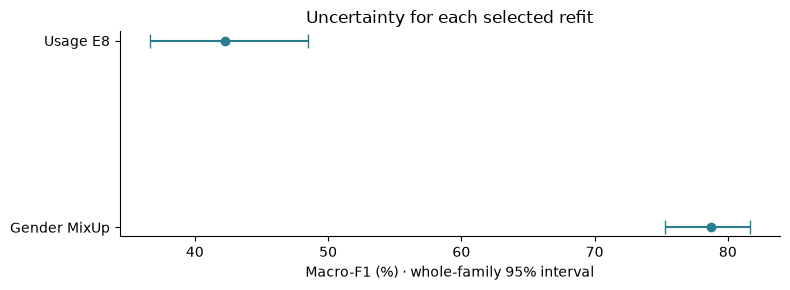

In [7]:
bootstrap_path = EVAL_ROOT/'reports/task3/gender_mixup_refit_holdout_20260911/selected_refit_bootstrap.json'
bootstrap = json.loads(bootstrap_path.read_text())
intervals = pd.DataFrame(bootstrap).T
intervals[['macro_f1', 'lower_95', 'upper_95']] *= 100
display(intervals[['macro_f1', 'lower_95', 'upper_95', 'families', 'draws']])
fig, ax = plt.subplots(figsize=(8, 3))
for y, (name, row) in enumerate(intervals.iterrows()):
    ax.errorbar(float(row.macro_f1), y,
        xerr=[[float(row.macro_f1-row.lower_95)], [float(row.upper_95-row.macro_f1)]],
        fmt='o', capsize=5, color='#287d8e')
ax.set(yticks=range(len(intervals)), yticklabels=intervals.index,
    xlabel='Macro-F1 (%) · whole-family 95% interval', title='Uncertainty for each selected refit')
fig.tight_layout()
fig.savefig(FINAL_FIGURES/'refit_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()


These intervals describe each model separately; they are not a test comparing Gender with
Usage. Families are the sampling unit because closely related products do not provide fully
independent evidence. Resampling cannot create missing classes or more independent examples.

The smallest Usage classes have only one to ten images. One correct Travel prediction out of
three can change the reported class result greatly. Home has no estimate of recall at all.
Gender's Unisex weakness is supported by 311 examples and is more than a single rare mistake.

One training seed and source-specific catalogue images limit the claim beyond these rows.
A separate collection of product families is needed to assess
transfer. More bootstrap draws alone would not solve that limitation.


## 10. Confidence quality and robustness limits

The predictions are raw softmax probabilities. NLL and Brier measure probability error; lower
values are better. ECE compares mean confidence with correctness in 15 bins. Its dependence on
binning means that a small ECE cannot by itself justify automatic publication [3].


Gender MixUp — predictions at confidence ≥0.90: 3889 ; wrong: 52
Usage E8 — predictions at confidence ≥0.90: 3697 ; wrong: 117


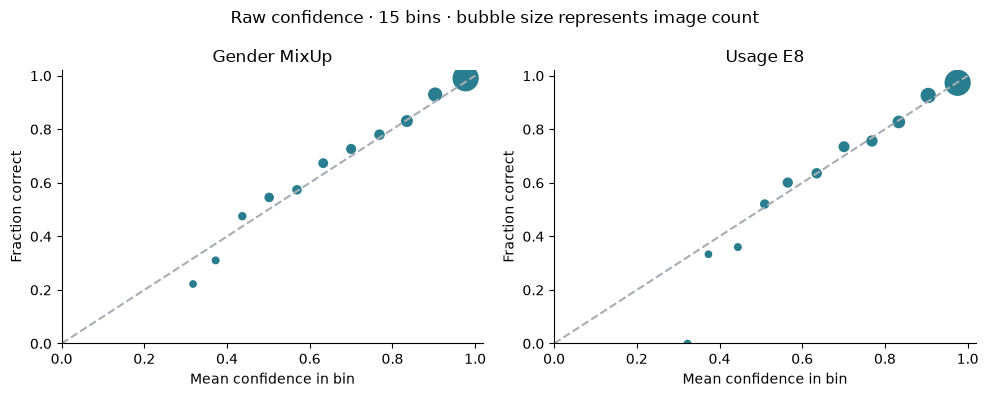

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, item) in zip(axes, evaluation.items()):
    bins = reliability_table(item)
    ax.plot([0, 1], [0, 1], '--', color='#a5adb5', label='Equal confidence and accuracy')
    ax.scatter(bins.confidence, bins.accuracy, s=20+300*bins.images/bins.images.max(), color='#287d8e')
    ax.set(title=name, xlabel='Mean confidence in bin', ylabel='Fraction correct', xlim=(0,1.02), ylim=(0,1.02))
    confident = item['rows'].loc[item['rows'].confidence.ge(.9)]
    print(name, '— predictions at confidence ≥0.90:', len(confident),
        '; wrong:', int(confident.actual.ne(confident.predicted).sum()))
fig.suptitle('Raw confidence · 15 bins · bubble size represents image count')
fig.tight_layout()
fig.savefig(FINAL_FIGURES/'refit_reliability.png', dpi=150, bbox_inches='tight')
plt.show()


Gender has NLL 0.2873, Brier 0.1444 and ECE 1.70%. Usage has NLL 0.3173, Brier 0.1706 and
ECE 0.95%. These different targets should not be ranked solely by those values. Usage's small
aggregate ECE can coexist with very low precision for rare occasions, because common classes
dominate the image count. The plot and printed wrong high-confidence predictions make that
limitation visible. Guo et al. [3] found that modern neural networks can be poorly calibrated
and that temperature scaling often improves calibration on their tested datasets. Here, the
small overall ECE values do not remove the observed rare-class errors. Their work supports
checking confidence separately from accuracy; it does not establish that our class-level
confidence is reliable. No threshold or calibration transform is fitted from this evaluation.

The refits have **no separate corruption benchmark**. Mild-corruption development tests scored
different fold checkpoints. Those results cannot be assigned to these full-development weights.
This final assessment is therefore about clean catalogue images. It does not establish tolerance
to phone photos, severe crops, new backgrounds or a different retailer.


## 11. Gender — Ultimate judgement

**The selected MixUp refit supports reviewed catalogue suggestions.** Its 78.74% macro-F1 and
90.46% accuracy show useful recognition on the scored catalogue images, while 551 mistakes
make reliable unattended tagging an unsupported claim. The development notebook establishes
why this recipe was chosen; the final evaluation describes the resulting artifact's behaviour.

The strongest results are Men and Women. Boys and Girls suggestions are correct about seven
times in ten, and Unisex recall is only 54.98%. This suggests that images alone may be insufficient
for overlapping audience labels. Product text and sizing are possible sources of added evidence
for future work. A model
prediction does not establish a person's gender or an item's exclusive audience.

Radenović et al. [1] found that trainable GeM pooling improved image retrieval on benchmarks
such as Oxford Buildings and Paris. This motivates pooling that emphasises strong visual
responses, but our fixed-p=3 GeM model is trained from scratch for fashion classification.
Its 78.74% macro-F1 cannot be compared directly with their retrieval scores.

Zhang et al. [2] found that MixUp, which blends training images and their labels, improved
generalisation on datasets including CIFAR and ImageNet. Our selected MixUp refit produces
useful audience suggestions, yet its 54.98% Unisex recall shows that overlapping labels remain
difficult. This final evaluation measures the whole recipe; it does not isolate the benefit of
MixUp or GeM. The different images, labels and training setup also limit comparison with those
papers. A useful next experiment would compare otherwise identical models with and without
each method on the development folds, followed by evaluation on fresh unseen data. This would
help separate the contribution of each method from the performance of the combined recipe.

There is no measured human time saving or validated automatic-publish policy. Future work
could test a workflow with manual correction on a shop's own product families, measuring
correction time and the cost of wrong tags before drawing claims about practical value.


## 12. Usage — Ultimate judgement

**The selected E8 refit is a limited suggestion tool.** Its 42.26% nine-class macro-F1 is much
weaker than its 88.70% accuracy suggests. Common occasions provide useful signal, but rare
occasions remain poorly recognised and often wrongly suggested. It makes 653 label errors on
the evaluation set. Five correct rare-class labels out of 22 do not support dependable rare-class
tagging.

Cui et al. [4] found that weighting by the effective number of samples improved performance
on imbalanced benchmarks including long-tailed CIFAR and iNaturalist. This supports giving
sparse classes more influence during learning. Our weighted E8 recipe still recognises only
five of 22 rare-class examples, so that method does not ensure dependable rare-occasion tags
here. Fashion occasions have different labels and visual cues from those benchmarks, and
this final evaluation does not isolate weighting from the rest of the recipe. Weighting and
translation augmentation cannot supply missing visual evidence or settle overlapping occasion
definitions. The final counts show that these remain practical limits.

The main lesson is that high overall accuracy and confidence can hide weak rare-class
recognition. Future work could examine clearer occasion definitions and more varied, reviewed
rare-class examples. A workflow study could also test editable suggestions and an option to
leave uncertain tags unset within the nine-class scheme. Whether this reduces staff work
remains an open question.


## 13. Compute cost and practical workload

Training time below describes the single completed refit, excluding development search and data
review. Peak allocated GPU memory is training memory, not serving RAM. Checkpoint size measures
disk storage. The CPU prediction timings include image preprocessing but are single recorded
batched passes, not repeated latency benchmarks or an application response-time guarantee.


In [9]:
cost_rows = []
for name, item in evaluation.items():
    model, receipt = item['manifest'], item['evaluation']
    training, freeze = receipt['training'], item['freeze']
    seconds = freeze['inference_seconds_including_image_preprocessing']
    cost_rows.append([name, model['parameter_count'],
        (EVAL_ROOT/model['checkpoint']['path']).stat().st_size/2**20,
        training['train_seconds']/60, training['peak_memory_bytes']/2**20,
        seconds, seconds/5778*1000, 1])
display(pd.DataFrame(cost_rows, columns=['Model', 'Parameters', 'Checkpoint MiB',
    'Fit minutes', 'Peak training GPU MiB', 'CPU pass seconds',
    'Amortized ms/image', 'Network passes/image']).set_index('Model').round(3))
display((summary[['Wrong']].assign(**{'Observed errors per 1,000':summary.Wrong/summary.Images*1000})).round(2))


,Parameters,Checkpoint MiB,Fit minutes,Peak training GPU MiB,CPU pass seconds,Amortized ms/image,Network passes/image
Model,,,,,,,
Gender MixUp,390181,1.506,9.330,454.524,11.817,2.045,1
Usage E8,391209,1.511,8.813,429.229,11.453,1.982,1


,Wrong,"Observed errors per 1,000"
Model,,
Gender MixUp,551,95.36
Usage E8,653,113.01


Gender records about 9.33 training minutes and Usage 8.81. Their training hardware and runtime
versions differ, so these are receipts rather than a fair speed contest. Each prediction needs
one network pass. The Gender CPU pass used PyTorch 2.13, while the saved Usage pass used 2.11;
even similar timings do not prove identical serving performance.

The observed workload is about 95 wrong Gender tags and 113 wrong Usage tags per 1,000 scored
images. These are separate tag decisions, not counts of distinct products that should be added.
No staff correction times, labour rates or financial savings were measured. To establish value,
measure review time and error cost against manual entry in the intended workflow.


## 14. Selected-model handoff and official predictions

Use the exact Gender MixUp and Usage E8 checkpoints verified in Section 4. Their saved colour
statistics and class order are part of each model. One checkpoint supplies each target's entire
prediction. The inference code must select these explicit artifacts rather than assume a
generic model folder contains the selected weights.

The official output format remains `id,gender,articleType,season,usage`. The teacher did not
supply test labels; no test score is reported. This notebook assesses the internal holdout and
does not create the complete four-target official prediction file or deploy an application.
The team must combine all four targets and check the submission separately.

For a catalogue workflow, show each predicted tag beside the photo as an editable suggestion.
Staff review it against product details, correct or leave it unset, then approve publication.
Store the model version and approved tag so mistakes can be audited. Keep manual entry available
if prediction fails. This is the proposed workflow, not evidence of an implemented or tested GUI.


## 15. Limits and future work

The most useful next evidence is a separate collection of product families from the intended
shop, with clear reference labels and enough examples for the weak classes. Define acceptable
error costs before opening that collection. Do not use this scored holdout to choose another
training recipe.

For Gender, review Unisex meaning and ambiguous child/adult products. For Usage, collect
independent rare-class families and resolve overlapping occasion definitions. Product text or
sizing could add information, but any multimodal extension needs its own development comparison
and a fresh evaluation. More model capacity alone is not established as the remedy.

Test the exact refits on realistic image changes before claiming robustness. Measure repeated
serving latency, memory, correction rate and staff time before promising operational savings.
The present results describe saved-model behaviour on this catalogue population with one
training seed. Performance on other product collections remains to be measured.


## 16. References

[1] F. Radenović, G. Tolias, and O. Chum, [“Fine-Tuning CNN Image Retrieval with No Human Annotation,”](https://arxiv.org/abs/1711.02512) IEEE TPAMI, 2019.

[2] H. Zhang, M. Cissé, Y. N. Dauphin, and D. Lopez-Paz, [“mixup: Beyond Empirical Risk Minimization,”](https://arxiv.org/abs/1710.09412) ICLR, 2018.

[3] C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger, [“On Calibration of Modern Neural Networks,”](https://proceedings.mlr.press/v70/guo17a.html) ICML, 2017.

[4] Y. Cui, M. Jia, T.-Y. Lin, Y. Song, and S. Belongie, [“Class-Balanced Loss Based on Effective Number of Samples,”](https://arxiv.org/abs/1901.05555) CVPR, 2019.
